In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

In [20]:
data = {
"Area_sqft":[1200,1500,1800,2400,3000,3500,900,1100,2000,2600,3200,4000,1400,1700,2100,2800,3600,4200,950,1250,1750,2250,2750,3300,3800,4100,1000,1600,1900,2500],
"Bedrooms":[2,3,3,4,4,5,2,2,3,4,4,5,3,3,4,4,5,5,2,2,3,3,4,4,5,5,2,3,3,4],
"Bathrooms":[2,2,3,3,4,4,1,2,3,3,4,5,2,2,3,3,4,5,1,2,2,3,3,4,4,5,1,2,3,3],
"Floors":[1,2,2,2,2,3,1,1,2,2,3,3,1,2,2,2,3,3,1,1,2,2,2,3,3,3,1,2,2,2],
"Age_of_house":[10,5,8,6,3,2,15,12,7,4,2,1,9,6,5,4,3,1,14,11,8,7,6,4,3,2,16,10,7,5],
"Price":[150000,200000,250000,320000,400000,480000,100000,130000,270000,350000,420000,550000,180000,230000,290000,360000,470000,600000,110000,140000,220000,280000,340000,410000,500000,580000,120000,210000,260000,330000]
}

In [21]:
df=pd.DataFrame(data)

In [22]:
X=df[["Area_sqft","Bedrooms","Bathrooms","Floors","Age_of_house"]]
y=df["Price"]

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [24]:
scaler=StandardScaler()

In [25]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [26]:
reg=LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
mse=cross_val_score(reg,X_train,y_train,cv=10,scoring="neg_mean_squared_error")

In [28]:
np.mean(mse)

np.float64(-169456318.87486893)

In [29]:
predict_reg=reg.predict(X_test)

In [30]:
predict_reg

array([212374.30666623, 358174.00856866, 442313.84888879, 563910.10390834,
       268353.88292835, 338722.30573417, 258628.03151111, 506272.4918566 ])

In [31]:
y_test

27    210000
15    360000
23    410000
17    600000
8     270000
9     350000
28    260000
24    500000
Name: Price, dtype: int64

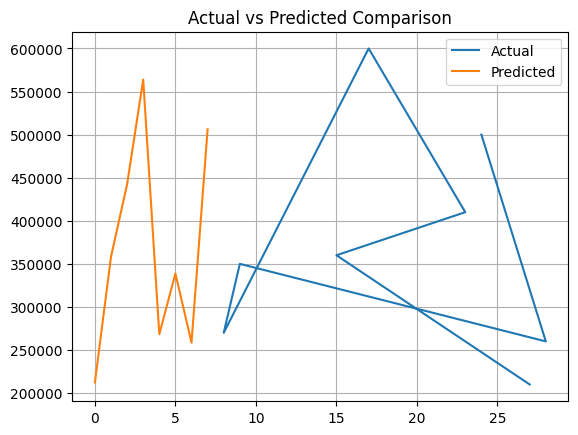

In [32]:
plt.plot(y_test, label="Actual")
plt.plot(predict_reg, label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Comparison")
plt.grid()
plt.show()

In [33]:
r2=r2_score(y_test,predict_reg)

In [16]:
r2

6.822540943152156e-05